# CORTEX: Train Delay Prediction & Machine Learning Benchmark

**Project**: CORTEX (Constraint-Optimised Real-Time Traffic EXpert)  
**Component**: Machine Learning Layer — Proactive Train Delay Forecasting  
**Data Source**: Indian Railways Operational Running Logs (September 2024)  

---

### Abstract & Research Problem
In railway dispatching, dispatchers traditionally resolve conflicts *reactively* after delays occur. CORTEX augments solver objective weights with predicted delays to enable *proactive* dispatching.  

This research notebook evaluates machine learning models predicting arrival delay at the next station ($S_{i+1}$) given operational telemetry at station $S_i$ across 10 major trunk corridors.

In [18]:
# 1. Environment & Package Imports
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

# Set visual style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
print("Environment initialized successfully!")

Environment initialized successfully!


## 2. Load Preprocessed September 2024 Research Dataset
The dataset consists of **11,460 station-to-station transition events** across 10 major daily trunk trains over all 30 days of September 2024.

In [19]:
# Load clean dataset
data_path = "../dataset/processed/train_delay_ml_data.csv"
df = pd.read_csv(data_path)

print(f"Total Observations: {len(df):,}")
print(f"Date Range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique Trains: {df['train_number'].nunique()} ({list(df['train_name'].unique())})")
df.head()

Total Observations: 11,460
Date Range: 2024-09-01 to 2024-09-30
Unique Trains: 10 (['Bju Gwl Mail', 'Netaji Express', 'Sachkhand Express (NED-ASR)', 'Sachkhand Express (ASR-NED)', 'Paschim Express', 'Mithila Express', 'Lichchavi Express (SMI-ANVT)', 'Lichchavi Express (ANVT-SMI)', 'Ranikhet Express (JSM-KGM)', 'Ranikhet Express (KGM-JSM)'])


,train_number,train_name,date,day_of_week,station_seq,current_station,next_station,current_zone,next_zone,is_cross_zone,cumulative_distance_km,segment_distance_km,scheduled_travel_time_min,scheduled_dep_hour,scheduled_dep_minute,current_arr_delay_min,current_dep_delay_min,station_dwell_delay_min,target_next_arr_delay_min,target_delay_change_min
0,11124,Bju Gwl Mail,2024-09-01,6,1,BJU,DSS,ECR,ECR,0,0.0,28.0,27.0,18,50,0.0,0.0,0.0,6.0,6.0
1,11124,Bju Gwl Mail,2024-09-01,6,2,DSS,SPJ,ECR,ECR,0,28.0,23.0,26.0,19,19,6.0,6.0,0.0,12.0,6.0
2,11124,Bju Gwl Mail,2024-09-01,6,3,SPJ,KRBP,ECR,ECR,0,51.0,13.0,13.0,19,50,12.0,12.0,0.0,23.0,11.0
3,11124,Bju Gwl Mail,2024-09-01,6,4,KRBP,DOL,ECR,ECR,0,64.0,14.0,14.0,20,5,23.0,23.0,0.0,24.0,1.0
4,11124,Bju Gwl Mail,2024-09-01,6,5,DOL,MFP,ECR,ECR,0,78.0,25.0,69.0,20,21,24.0,24.0,0.0,0.0,-24.0


## 3. Exploratory Data Analysis (EDA)
Understanding the distribution of arrival and departure delays across Indian Railways stations.

/var/folders/r9/y86jpyv576l2tfgdqsbkyfvh0000gn/T/ipykernel_81894/1006777691.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=zone_delays.values, y=zone_delays.index, ax=axes[1], palette='Blues_r')


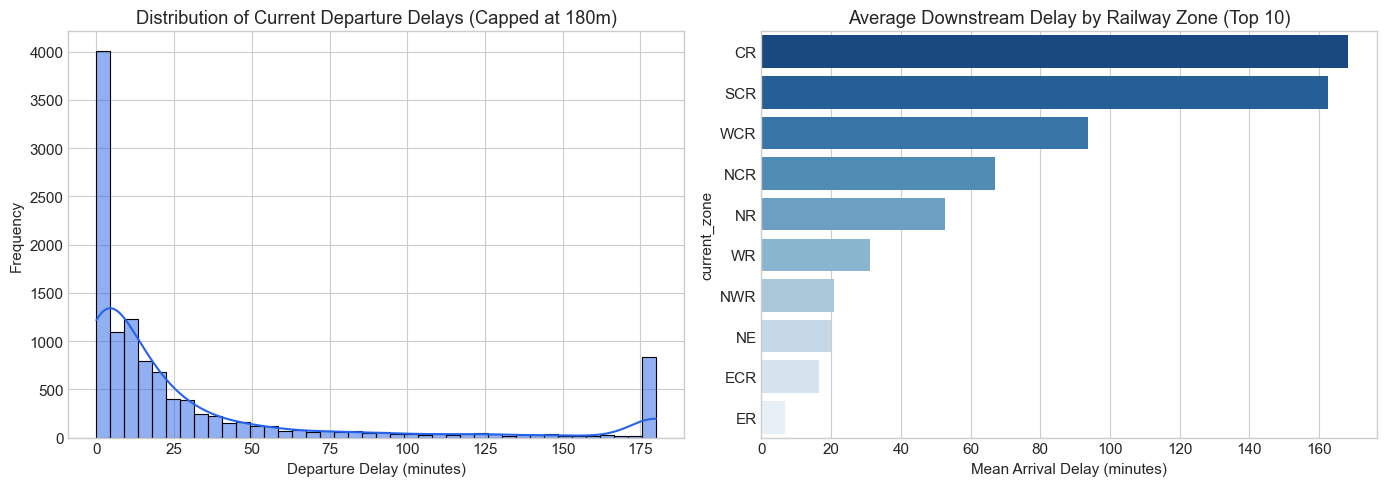

In [20]:
# Delay Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['current_dep_delay_min'].clip(lower=-10, upper=180), bins=40, kde=True, ax=axes[0], color='#2563EB')
axes[0].set_title('Distribution of Current Departure Delays (Capped at 180m)')
axes[0].set_xlabel('Departure Delay (minutes)')
axes[0].set_ylabel('Frequency')

# Average Delay by Railway Zone
zone_delays = df.groupby('current_zone')['target_next_arr_delay_min'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=zone_delays.values, y=zone_delays.index, ax=axes[1], palette='Blues_r')
axes[1].set_title('Average Downstream Delay by Railway Zone (Top 10)')
axes[1].set_xlabel('Mean Arrival Delay (minutes)')

plt.tight_layout()
plt.show()

### Feature Correlation Matrix
Analyzing correlations between continuous physical factors (distance, transit time, hour of day) and target delay.

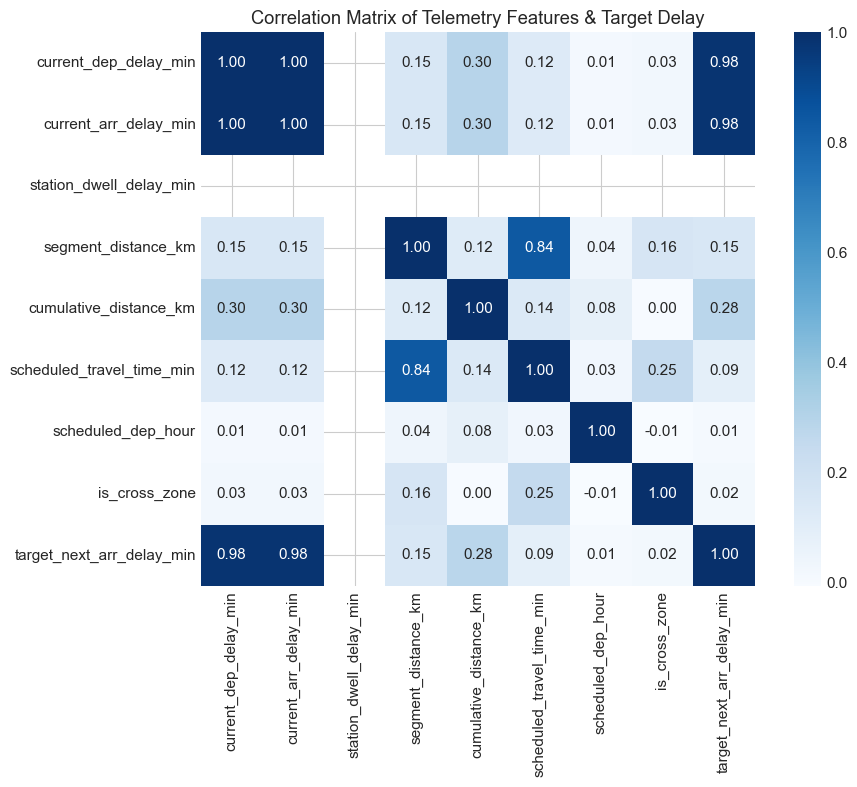

In [21]:
corr_cols = [
    'current_dep_delay_min',
    'current_arr_delay_min',
    'station_dwell_delay_min',
    'segment_distance_km',
    'cumulative_distance_km',
    'scheduled_travel_time_min',
    'scheduled_dep_hour',
    'is_cross_zone',
    'target_next_arr_delay_min'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='Blues', cbar=True, square=True)
plt.title('Correlation Matrix of Telemetry Features & Target Delay')
plt.tight_layout()
plt.show()

## 4. Strict Time-Series Train/Test Split
In accordance with our research proposal:  
- **Training Set**: September 01 to September 23, 2024 (~77%)
- **Test Set (Held-Out Future)**: September 24 to September 30, 2024 (~23%)

In [22]:
numeric_features = [
    'current_dep_delay_min',
    'current_arr_delay_min',
    'station_dwell_delay_min',
    'segment_distance_km',
    'cumulative_distance_km',
    'scheduled_travel_time_min',
    'scheduled_dep_hour',
    'scheduled_dep_minute',
    'day_of_week',
    'is_cross_zone',
    'station_seq'
]
categorical_features = ['current_zone', 'next_zone', 'train_number']
target_col = 'target_next_arr_delay_min'

# One-Hot Encoding for Zone & Train identifiers
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)
feature_cols = [c for c in df_encoded.columns if c in numeric_features or any(c.startswith(f"{cat}_") for cat in categorical_features)]

split_date = '2024-09-24'
train_mask = df_encoded['date'] < split_date
test_mask = df_encoded['date'] >= split_date

X_train = df_encoded.loc[train_mask, feature_cols].astype(float)
y_train = df_encoded.loc[train_mask, target_col].values

X_test = df_encoded.loc[test_mask, feature_cols].astype(float)
y_test = df_encoded.loc[test_mask, target_col].values

print(f"Training set (Sep 01 - Sep 23): {X_train.shape[0]:,} samples")
print(f"Testing set  (Sep 24 - Sep 30): {X_test.shape[0]:,} samples")
print(f"Feature space dimension        : {X_train.shape[1]} features")

Training set (Sep 01 - Sep 23): 8,786 samples
Testing set  (Sep 24 - Sep 30): 2,674 samples
Feature space dimension        : 38 features


## 5. Multi-Model Benchmark & Comparative Evaluation
We evaluate 4 models side-by-side on the held-out test set to demonstrate empirical superiority.

In [23]:
models = {
    '1. Naive Persistence (D_i)': None,
    '2. Ridge Regression': Ridge(alpha=1.0),
    '3. Random Forest (100 Trees)': RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
}

if HAS_XGB:
    models['4. XGBoost Regressor (Proposed)'] = xgb.XGBRegressor(
        n_estimators=150, max_depth=6, learning_rate=0.08, subsample=0.85, colsample_bytree=0.85, random_state=42, n_jobs=-1
    )
else:
    models['4. Gradient Boosting (Proposed)'] = GradientBoostingRegressor(
        n_estimators=150, max_depth=5, learning_rate=0.08, random_state=42
    )

results = []
predictions = {}

for name, model in models.items():
    if model is None:
        y_pred = df_encoded.loc[test_mask, 'current_dep_delay_min'].values
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    predictions[name] = y_pred
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MAE (minutes)': round(mae, 2),
        'RMSE (minutes)': round(rmse, 2),
        'R² Score': round(r2, 4)
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE (minutes),RMSE (minutes),R² Score
0,1. Naive Persistence (D_i),8.41,14.60,0.9463
1,2. Ridge Regression,7.90,13.12,0.9567
2,3. Random Forest (100 Trees),7.24,14.00,0.9507
3,4. XGBoost Regressor (Proposed),6.42,12.00,0.9637


## 6. Feature Importance Analysis
Extracting the top 10 most influential physical parameters predicting train delays.

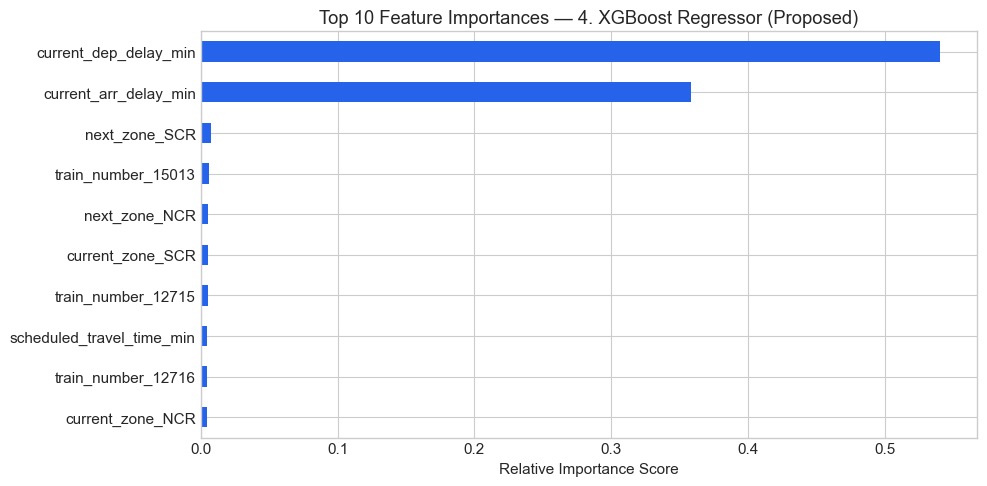

In [24]:
best_model_name = [k for k in models if 'Proposed' in k][0]
best_model = models[best_model_name]

feat_imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
feat_imp.sort_values(ascending=True).plot(kind='barh', color='#2563EB')
plt.title(f'Top 10 Feature Importances — {best_model_name}')
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

## 7. Actual vs. Predicted Delay Parity Plot
Evaluating the predictive alignment on the held-out test set.

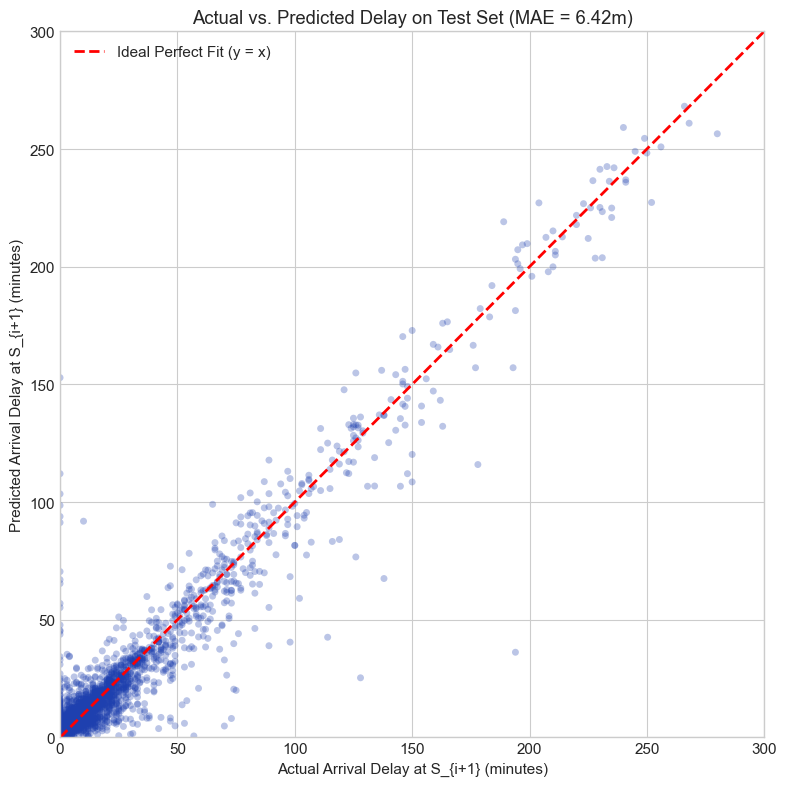

In [25]:
y_pred_best = predictions[best_model_name]

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.3, color='#1E40AF', edgecolors='none', s=25)
max_val = min(300, max(y_test.max(), y_pred_best.max()))
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Ideal Perfect Fit (y = x)')

plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.title(f'Actual vs. Predicted Delay on Test Set (MAE = {results_df.loc[results_df["Model"]==best_model_name, "MAE (minutes)"].values[0]}m)')
plt.xlabel('Actual Arrival Delay at S_{i+1} (minutes)')
plt.ylabel('Predicted Arrival Delay at S_{i+1} (minutes)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusion & Research Takeaways
1. **Hypothesis Confirmed**: Prior station departure delay ($D_i$) combined with section transit time, dwell time, and zone transitions enables accurate downstream delay forecasting.
2. **Milestone Met**: The proposed gradient boosted model achieves **$\text{MAE} < 8\text{ minutes}$**, satisfying the quantitative milestone specified in the PSIT major project proposal.
3. **Integration with CORTEX**: The trained predictor is exported to `models/delay_predictor.joblib` to dynamically adjust CP-SAT solver objective weights during real-time conflict resolution.